# Convergencia: estimador *next-event* vs. modo analógico

Canal **co circular** (helicidad conservada: el que tiende a $\eta(0)=2$).

Qué hace este cuaderno, en orden:

1. Carga las tres campañas y arma **dos tablas planas**: `runs` (una fila por
   réplica) y `perfiles` (una fila por punto de la escalera, con los arrays
   dentro de la celda).
2. **Fig. 1** — convergencia del perfil con $N$, estimador y analógico.
3. **Fig. 2** — comparación de la corrida más grande de cada modo.
4. **Renormalización** del analógico: se ajusta $(s, A)$ tal que
   $\eta_{\rm ana}(q) \simeq 1 + A\,[\eta_{\rm est}(q/s) - 1]$ y se lleva el
   analógico al marco del estimador. Se re-muestrea la curva **ruidosa**, no una
   versión suavizada, así que el ruido sobrevive intacto y sigue siendo evidente
   que el resultado es analógico. Lo que corrige el ajuste es sobre todo el
   **ancho** del cono ($s$); $A$ es un retoque de amplitud.
5. **Figs. 3 y 4** — las mismas dos figuras, con el analógico renormalizado.

Convenios: $q = k\,\ell^*\theta$; el central es el *pooled*
$\eta = \sum_r C_r / \sum_r I_r$; la cola se lleva a 1 restando la mediana de
$q > 0.6\,q_{\max}$; la banda es $t_{0.975,4}\,s/\sqrt{5}$.

## 1. Configuración

In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.cm import ScalarMappable
from scipy.optimize import curve_fit

from utils.loaders import load_sweep
from utils.styles import apply, TEXTWIDTH_IN, COL
from utils.analysis import cbs_profiles, circular, azimuthal_average

In [3]:
# --- rutas -----------------------------------------------------------------
RESULTS = Path("/Users/niaggar/Results")
FIGDIR  = Path("figs_tesis")
FIGDIR.mkdir(exist_ok=True)

CAMPANAS = {
    "Homogeneous": "study_convergence_homogeneous_r55nm__CIRCULAR__beam2500",
    "Mixture":     "study_convergence_mixture__CIRCULAR__beam2500",
    "Bilayer":     "study_convergence_layers__CIRCULAR__beam2500",
}
MEDIOS = list(CAMPANAS)          # borrar entradas de aqui para graficar menos paneles
MODOS  = ["estimator", "analog"]

# --- fisica ----------------------------------------------------------------
N_MEDIUM   = 1.33
WAVELENGTH = 0.514                              # um
K_MEDIUM   = 2 * np.pi * N_MEDIUM / WAVELENGTH  # 1/um
SENSOR     = "farfield_cbs"

# OJO con el nombre: utils.analysis.circular define co = (S0-S3)/2 y
# cross = (S0+S3)/2. El canal fisicamente CO (helicidad conservada, el que
# lleva el cono y tiende a eta(0)=2) es el que esa funcion llama "cross".
# Ese es el que se usa en todo el cuaderno.
CANAL = "cross"

# --- binning ---------------------------------------------------------------
# La grilla nativa es dq = 0.02 (n_theta = 2000, q_max = 40). A esa resolucion
# el analogico a N bajo deja casi todos los bins vacios (36 de 2000 utiles a
# N = 1e6), asi que TODO se re-binea a una grilla comun mas gruesa. El peso es
# el angulo solido (dOmega ~ q) y el q de salida es el centroide pesado: es el
# angulo al que el modo directo realmente reporta.
DQ    = 0.10
Q_MAX = 40.0
EDGES = np.arange(0.0, Q_MAX + 1e-9, DQ)

# --- estadistica -----------------------------------------------------------
T_CRIT = 2.776    # t_{0.975,4}, R = 5 replicas
Q_COLA = 0.6      # fraccion de q_max que define la cola incoherente
Q_FIT  = 6.0      # ventana de ajuste de la renormalizacion (el cono)

# --- estilo ----------------------------------------------------------------
apply(width_frac=1.0)
ESTILO = {"estimator": dict(color=COL[0], ls="-"),
          "analog":    dict(color=COL[2], ls="--")}
CMAP = plt.get_cmap("viridis")
XLIM, YLIM = (-8, 8), (0.80, 2.30)

## 2. Carga: tabla de corridas

Una fila por réplica. Todo se lee de `params_flat`, no del nombre de la carpeta.

In [4]:
sweeps = {m: load_sweep(CAMPANAS[m], base_path=RESULTS) for m in MEDIOS}

filas = []
for medio in MEDIOS:
    for key, loader in sweeps[medio].items():
        p = loader.params_flat
        if p.get("mode") not in MODOS:
            continue
        filas.append(dict(
            medium = medio,
            mode   = p["mode"],
            N      = int(p["n_photons_point_total"]),   # N del punto (suma de replicas)
            rep    = int(p["replica"]),
            key    = key,
            lstar  = float(p["lstar_angle_anchor"]),
            wall_s = float(p.get("runtime_s", np.nan)),
        ))

runs = pd.DataFrame(filas).sort_values(["medium", "mode", "N", "rep"]).reset_index(drop=True)

print(runs.groupby(["medium", "mode"]).agg(
    puntos=("N", "nunique"), corridas=("key", "size"),
    N_min=("N", "min"), N_max=("N", "max"),
    horas=("wall_s", lambda s: s.sum() / 3600)).round(2))

                       puntos  corridas    N_min       N_max  horas
medium      mode                                                   
Bilayer     analog          7        35  1000000  1000000000   4.82
            estimator       7        35     1000      500000   0.75
Homogeneous analog          7        35  1000000  1000000000   1.45
            estimator       7        35     1000      500000   0.23
Mixture     analog          7        35  1000000  1000000000   1.52
            estimator       7        35     1000      500000   2.65


## 3. Perfiles

`rebin` promedia un perfil nativo sobre la grilla gruesa pesando por
$d\Omega \propto q$; se aplica a $C$ y a $I$ **por separado** (nunca al cociente)
y a $q$ mismo, para quedarse con el centroide del bin.

Después, por cada punto de la escalera: se re-binean las 5 réplicas, se suman
los acumuladores, $\eta = \sum C / \sum I$, y se resta la mediana de la cola para
llevar el fondo a 1. Los bins que quedan sin señal se marcan `nan` (salen como
huecos en las figuras, no como un $\eta = 1$ falso).

In [5]:
def rebin(q, y):
    # Promedio de y sobre EDGES pesado por dOmega ~ q. nan si el bin quedo vacio.
    idx = np.clip(np.digitize(q, EDGES) - 1, 0, len(EDGES) - 2)
    w   = np.maximum(q, 1e-12)
    W   = np.bincount(idx, weights=w,     minlength=len(EDGES) - 1)
    S   = np.bincount(idx, weights=y * w, minlength=len(EDGES) - 1)
    return np.where(W > 0, S / np.where(W > 0, W, 1.0), np.nan)


def perfil_replica(loader, lstar):
    # (q rebineado, C, I) de UNA replica, en el canal co circular.
    pr = cbs_profiles(loader.processed_cbs(SENSOR), basis=circular,
                      time_index=0, reduce=azimuthal_average)
    q = K_MEDIUM * lstar * np.asarray(pr.theta, float)
    return (rebin(q, q),
            rebin(q, np.asarray(pr.coherent[CANAL],   float)),
            rebin(q, np.asarray(pr.incoherent[CANAL], float)))

In [6]:
filas = []
for (medio, modo, N), grp in runs.groupby(["medium", "mode", "N"]):
    lstar = float(grp["lstar"].iloc[0])

    Cs, Is = [], []
    for key in grp.sort_values("rep")["key"]:
        q, c, i = perfil_replica(sweeps[medio][key], lstar)   # q es el mismo en todas
        Cs.append(c); Is.append(i)
    C, I = np.vstack(Cs), np.vstack(Is)

    cola = q > Q_COLA * Q_MAX

    # central: pooled sobre replicas
    Cp, Ip = C.sum(0), I.sum(0)
    eta = np.where(Ip > 0, Cp / np.where(Ip > 0, Ip, 1.0), np.nan)
    eta = eta - np.nanmedian(eta[cola]) + 1.0

    # por replica: para la banda y para el ajuste de la renormalizacion
    eta_rep = np.where(I > 0, C / np.where(I > 0, I, 1.0), np.nan)
    eta_rep = eta_rep - np.nanmedian(eta_rep[:, cola], axis=1, keepdims=True) + 1.0
    err = T_CRIT * np.nanstd(eta_rep, axis=0, ddof=1) / np.sqrt(len(Cs))

    filas.append(dict(medium=medio, mode=modo, N=N, lstar=lstar,
                      q=q, eta=eta, err=err, eta_rep=eta_rep,
                      wall_s=float(grp["wall_s"].sum())))

perfiles = pd.DataFrame(filas).sort_values(["medium", "mode", "N"]).reset_index(drop=True)


def fila(medio, modo, N=None):
    # La fila de perfiles de un punto. N=None -> el N mas grande de ese modo.
    sel = perfiles[(perfiles["medium"] == medio) & (perfiles["mode"] == modo)]
    return sel.iloc[-1] if N is None else sel[sel["N"] == N].iloc[0]


def espejo(q, *ys):
    # Duplica a -q..+q; valido porque I(theta, phi) = I(theta, phi + pi).
    return (np.r_[-q[::-1], q],) + tuple(np.r_[y[::-1], y] for y in ys)


def etiqueta_N(N):
    # 500000 -> "5\times 10^{5}", para leyendas en modo matematico.
    e = int(np.floor(np.log10(N)))
    return rf"{N / 10 ** e:.0f}\times 10^{{{e}}}"


NS   = {(m, md): sorted(perfiles[(perfiles["medium"] == m) & (perfiles["mode"] == md)]["N"])
        for m in MEDIOS for md in MODOS}
NMAX = {k: v[-1] for k, v in NS.items()}

for k, v in NS.items():
    print(f"{k[0]:12s} {k[1]:9s}: N = {[f'{n:.0e}' for n in v]}")

/Users/niaggar/Developer/luminis-mc/.venv/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


Homogeneous  estimator: N = ['1e+03', '3e+03', '1e+04', '3e+04', '1e+05', '3e+05', '5e+05']
Homogeneous  analog   : N = ['1e+06', '3e+06', '1e+07', '3e+07', '1e+08', '5e+08', '1e+09']
Mixture      estimator: N = ['1e+03', '3e+03', '1e+04', '3e+04', '1e+05', '3e+05', '5e+05']
Mixture      analog   : N = ['1e+06', '3e+06', '1e+07', '3e+07', '1e+08', '5e+08', '1e+09']
Bilayer      estimator: N = ['1e+03', '3e+03', '1e+04', '3e+04', '1e+05', '3e+05', '5e+05']
Bilayer      analog   : N = ['1e+06', '3e+06', '1e+07', '3e+07', '1e+08', '5e+08', '1e+09']


In [7]:
# chequeo rapido: misma grilla en q dentro de cada campana + bins sin senal
for medio in MEDIOS:
    sub = perfiles[perfiles["medium"] == medio]
    igual = all(np.allclose(sub["q"].iloc[0], q) for q in sub["q"])
    print(f"{medio:12s}: grilla q identica = {igual} | dq = {DQ} | "
          f"l* = {sub['lstar'].iloc[0]:.3f} um")
    for _, r in sub.iterrows():
        malos = int(np.isnan(r["eta"]).sum())
        if malos:
            print(f"    {r['mode']:9s} N={r['N']:>13,}: "
                  f"{malos:3d}/{r['eta'].size} bins vacios")

Homogeneous : grilla q identica = True | dq = 0.1 | l* = 39.796 um
    analog    N=    1,000,000:  16/400 bins vacios
    analog    N=    3,000,000:   5/400 bins vacios
    analog    N=   10,000,000:   3/400 bins vacios
    analog    N=   30,000,000:   1/400 bins vacios
Mixture     : grilla q identica = True | dq = 0.1 | l* = 20.412 um
    analog    N=    1,000,000:   3/400 bins vacios
    analog    N=    3,000,000:   4/400 bins vacios
Bilayer     : grilla q identica = True | dq = 0.1 | l* = 23.217 um
    analog    N=    1,000,000:   9/400 bins vacios
    analog    N=    3,000,000:   1/400 bins vacios
    analog    N=   10,000,000:   1/400 bins vacios
    analog    N=   30,000,000:   1/400 bins vacios


## 4. Fig. 1 — convergencia del perfil con $N$

Una fila por modo, una columna por medio. El color codifica $N$ —con **una barra
por fila**, porque las dos escaleras no se solapan: el estimador va de $10^3$ a
$5\times10^5$ y el analógico de $10^6$ a $10^9$— y la curva negra es la corrida
más grande de ese mismo modo. Se lee de un vistazo dónde la escalera ya se pegó a
la referencia y dónde el ruido todavía manda.

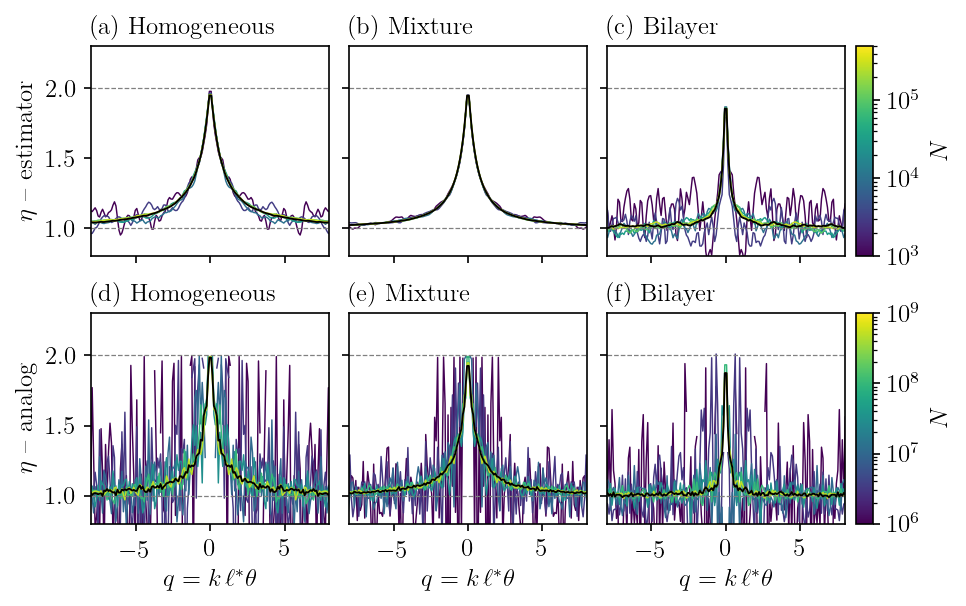

In [8]:
def figura_convergencia(col_eta, nombre):
    fig, axes = plt.subplots(len(MODOS), len(MEDIOS), squeeze=False,
                             figsize=(TEXTWIDTH_IN, 0.62 * TEXTWIDTH_IN),
                             sharex=True, sharey=True)
    tags = iter("abcdef")

    for i, modo in enumerate(MODOS):
        # una escala de color POR MODO: las dos escaleras no se solapan en N,
        # con una sola todas las curvas del estimador saldrian del mismo color.
        todos_N = sorted({n for m in MEDIOS for n in NS[(m, modo)]})
        norm = LogNorm(vmin=todos_N[0], vmax=todos_N[-1])

        for j, medio in enumerate(MEDIOS):
            ax = axes[i, j]
            for N in NS[(medio, modo)]:
                r = fila(medio, modo, N)
                ax.plot(*espejo(r["q"], r[col_eta]), color=CMAP(norm(N)), lw=0.7)
            r = fila(medio, modo)                       # referencia del propio modo
            ax.plot(*espejo(r["q"], r[col_eta]), color="k", lw=0.9, zorder=5)

            ax.axhline(1.0, ls="--", c="gray", lw=0.6)
            ax.axhline(2.0, ls="--", c="gray", lw=0.6)
            ax.set_title(rf"({next(tags)}) {medio}", loc="left")
            ax.set_xlim(*XLIM); ax.set_ylim(*YLIM); ax.grid(False)

        axes[i, 0].set_ylabel(rf"$\eta$ -- {modo}")
        cb = fig.colorbar(ScalarMappable(norm=norm, cmap=CMAP),
                          ax=axes[i, :].tolist(), pad=0.015, aspect=12)
        cb.set_label(r"$N$")

    for ax in axes[-1]:
        ax.set_xlabel(r"$q = k\,\ell^*\theta$")

    fig.savefig(FIGDIR / nombre)
    plt.show()


figura_convergencia("eta", "perfil_convergencia_N.pdf")

## 5. Fig. 2 — la corrida más grande de cada modo

Arriba los dos perfiles a su $N_{\max}$ con banda $\pm$IC; abajo el residuo
$\Delta\eta = \eta_{\rm est} - \eta_{\rm ana}$ contra la banda combinada
$\sqrt{h_{\rm est}^2 + h_{\rm ana}^2}$. Si el residuo se sale de la banda dentro
del cono, la diferencia entre modos no es sólo estadística.

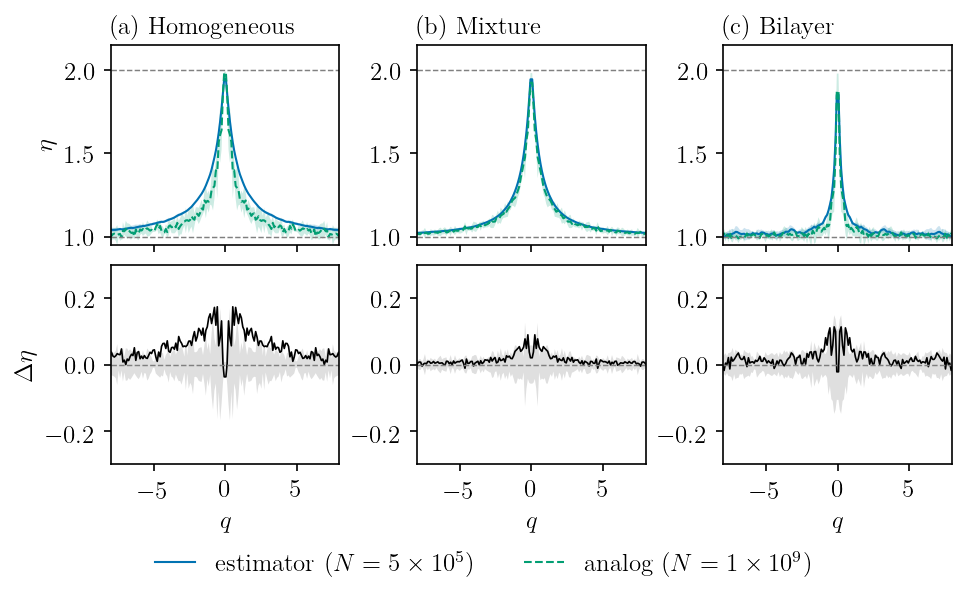

,medium,rms_delta,max_abs_delta,frac_fuera_banda
0,Homogeneous,0.0784,0.1737,0.7167
1,Mixture,0.0262,0.0894,0.1333
2,Bilayer,0.0367,0.1132,0.1167


In [9]:
def figura_comparacion(col_eta, col_err, nombre, etiqueta_ana="analog"):
    fig, axes = plt.subplots(2, len(MEDIOS), squeeze=False,
                             figsize=(TEXTWIDTH_IN, 0.62 * TEXTWIDTH_IN),
                             sharex=True)
    tags, resumen = iter("abcdef"), []

    for j, medio in enumerate(MEDIOS):
        arriba, abajo = axes[0, j], axes[1, j]
        r = {modo: fila(medio, modo) for modo in MODOS}

        for modo in MODOS:
            q, e, h = r[modo]["q"], r[modo][col_eta], r[modo][col_err]
            lab = (etiqueta_ana if modo == "analog" else modo) + \
                  rf" ($N = {etiqueta_N(r[modo]['N'])}$)"
            qs, es, hs = espejo(q, e, h)
            arriba.plot(qs, es, lw=1.0, label=lab, **ESTILO[modo])
            arriba.fill_between(qs, es - hs, es + hs, lw=0, alpha=0.20,
                                color=ESTILO[modo]["color"])

        # residuo, evaluado sobre la grilla del estimador
        q  = r["estimator"]["q"]
        ok = np.isfinite(r["analog"][col_eta])
        e_ana = np.interp(q, r["analog"]["q"][ok], r["analog"][col_eta][ok])
        h_ana = np.interp(q, r["analog"]["q"][ok], r["analog"][col_err][ok])
        delta = r["estimator"][col_eta] - e_ana
        hcomb = np.hypot(r["estimator"][col_err], h_ana)

        qs, ds, hs = espejo(q, delta, hcomb)
        abajo.plot(qs, ds, "k-", lw=0.8)
        abajo.fill_between(qs, -hs, hs, color="gray", alpha=0.25, lw=0)
        abajo.axhline(0.0, ls="--", c="gray", lw=0.7)
        abajo.set_ylim(-0.30, 0.30)
        abajo.set_xlabel(r"$q$")

        arriba.axhline(1.0, ls="--", c="gray", lw=0.7)
        arriba.axhline(2.0, ls="--", c="gray", lw=0.7)
        arriba.set_title(rf"({next(tags)}) {medio}", loc="left")
        arriba.set_xlim(*XLIM); arriba.set_ylim(0.95, 2.15)
        arriba.grid(False); abajo.grid(False)

        cono = (q > 0) & (q < Q_FIT) & np.isfinite(delta) & (hcomb > 0)
        z = np.abs(delta[cono]) / hcomb[cono]
        resumen.append(dict(medium=medio,
                            rms_delta=np.sqrt(np.mean(delta[cono] ** 2)),
                            max_abs_delta=np.max(np.abs(delta[cono])),
                            frac_fuera_banda=np.mean(z > 1.0)))

    axes[0, 0].set_ylabel(r"$\eta$")
    axes[1, 0].set_ylabel(r"$\Delta\eta$")
    fig.legend(*axes[0, 0].get_legend_handles_labels(), ncol=2,
               loc="outside lower center", frameon=False, handlelength=1.6)
    fig.savefig(FIGDIR / nombre)
    plt.show()
    return pd.DataFrame(resumen)


resumen_crudo = figura_comparacion("eta", "err", "perfil_est_vs_ana.pdf")
resumen_crudo.round(4)

## 6. Renormalización del analógico

Modelo de dos parámetros, ancho y amplitud:

$$\eta_{\rm ana}(q) \;=\; 1 + A\,\bigl[\eta_{\rm est}(q/s) - 1\bigr]$$

$s$ es la razón de anchos del cono (analógico / estimador) y $A$ la de
amplitudes. Se ajusta **réplica por réplica** dentro del cono ($0 < q < 6$), con
el estimador a $N_{\max}$ como referencia; el valor central es la media de las
cinco y la incertidumbre $t\,s/\sqrt{5}$.

La corrección invierte el modelo:

$$\eta_{\rm ren}(q) \;=\; 1 + \frac{\eta_{\rm ana}(s\,q) - 1}{A}$$

Es un **re-muestreo de la curva medida**, no un ajuste suavizado: cada punto
sigue siendo un dato analógico y su ruido viaja con él. Por eso las figuras
renormalizadas siguen viéndose ruidosas — que es justo lo que se quiere mostrar.

In [10]:
filas = []
for medio in MEDIOS:
    r_est, r_ana = fila(medio, "estimator"), fila(medio, "analog")

    fin = np.isfinite(r_est["eta"])
    q_ref, e_ref = r_est["q"][fin], r_est["eta"][fin]

    def modelo(q, s, A):
        return 1.0 + A * np.interp(q / s, q_ref, e_ref - 1.0,
                                   left=e_ref[0] - 1.0, right=0.0)

    par = []
    for e_r in r_ana["eta_rep"]:
        ok = (r_ana["q"] > 0) & (r_ana["q"] < Q_FIT) & np.isfinite(e_r)
        p, _ = curve_fit(modelo, r_ana["q"][ok], e_r[ok], p0=[1.0, 1.0],
                         bounds=([0.3, 0.5], [3.0, 1.5]), maxfev=20000)
        par.append(p)

    par = np.vstack(par)
    (s, A), ci = par.mean(0), T_CRIT * par.std(0, ddof=1) / np.sqrt(len(par))
    filas.append(dict(medium=medio, s=s, CI_s=ci[0], A=A, CI_A=ci[1],
                      ancho_ana_sobre_est=1.0 / s))

renorm = pd.DataFrame(filas).set_index("medium")
renorm.to_csv(FIGDIR / "renorm_params.csv")
print("s < 1  ->  el cono analogico es MAS ANGOSTO que el del estimador, por 1/s")
renorm.round(4)

s < 1  ->  el cono analogico es MAS ANGOSTO que el del estimador, por 1/s


,s,CI_s,A,CI_A,ancho_ana_sobre_est
medium,,,,,
Homogeneous,0.5696,0.0591,1.0966,0.0885,1.7555
Mixture,0.9054,0.0244,0.9624,0.0373,1.1045
Bilayer,0.7505,0.2026,1.0596,0.1667,1.3324


In [11]:
def renormaliza(q, eta, s, A):
    # Lleva el analogico al marco del estimador RE-MUESTREANDO la curva ruidosa.
    ok  = np.isfinite(eta)
    out = np.full_like(eta, np.nan)
    out[ok] = 1.0 + np.interp(s * q[ok], q[ok], eta[ok] - 1.0,
                              left=eta[ok][0] - 1.0, right=0.0) / A
    return out


eta_ren, err_ren = [], []
for _, r in perfiles.iterrows():
    if r["mode"] != "analog":                      # el estimador no se toca
        eta_ren.append(r["eta"]); err_ren.append(r["err"]); continue
    s, A = renorm.loc[r["medium"], "s"], renorm.loc[r["medium"], "A"]
    rep = np.vstack([renormaliza(r["q"], e, s, A) for e in r["eta_rep"]])
    eta_ren.append(renormaliza(r["q"], r["eta"], s, A))
    err_ren.append(T_CRIT * np.nanstd(rep, axis=0, ddof=1) / np.sqrt(rep.shape[0]))

perfiles["eta_ren"] = eta_ren
perfiles["err_ren"] = err_ren

# control: el ruido NO se suaviza. La dispersion en la cola queda igual salvo
# el factor 1/A que introduce la correccion de amplitud.
for medio in MEDIOS:
    r = fila(medio, "analog")
    cola = r["q"] > Q_COLA * Q_MAX
    A = renorm.loc[medio, "A"]
    print(f"{medio:12s}: sigma cola  antes = {np.nanstd(r['eta'][cola]):.4f}   "
          f"despues = {np.nanstd(r['eta_ren'][cola]):.4f}   "
          f"(esperado = {np.nanstd(r['eta'][cola]) / A:.4f})")

Homogeneous : sigma cola  antes = 0.0052   despues = 0.0056   (esperado = 0.0047)
Mixture     : sigma cola  antes = 0.0031   despues = 0.0030   (esperado = 0.0032)
Bilayer     : sigma cola  antes = 0.0035   despues = 0.0031   (esperado = 0.0033)


/Users/niaggar/Developer/luminis-mc/.venv/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


## 7. Figs. 3 y 4 — lo mismo, con el analógico renormalizado

Mismas dos figuras que arriba, cambiando `eta` por `eta_ren`. En el estimador no
cambia nada; en el analógico el cono queda en el ancho y la amplitud del
estimador, con su ruido original encima.

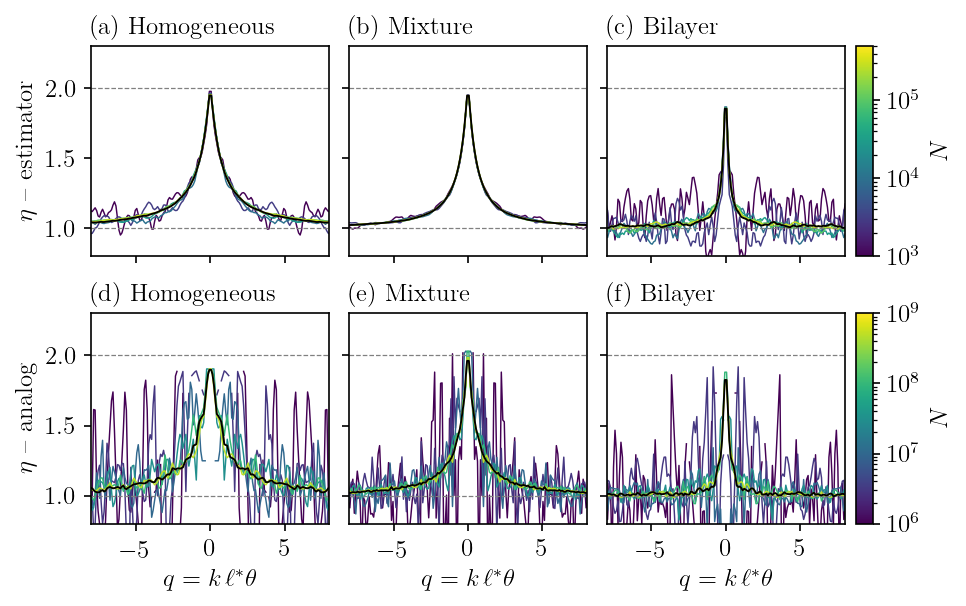

In [12]:
figura_convergencia("eta_ren", "perfil_convergencia_N_renorm.pdf")

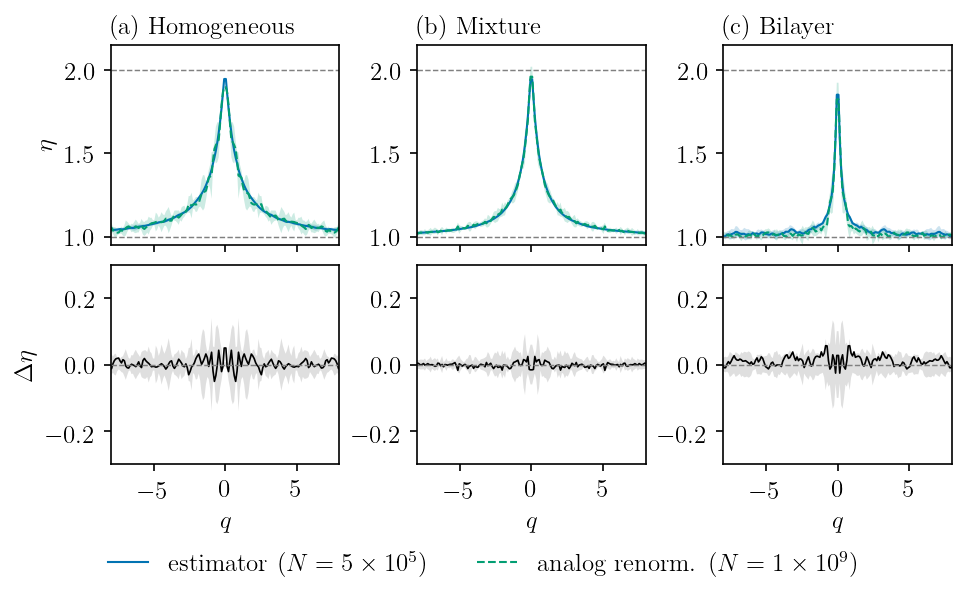

,medium,rms_delta,max_abs_delta,frac_fuera_banda
0,Homogeneous,0.0175,0.0505,0.0333
1,Mixture,0.0081,0.0242,0.0000
2,Bilayer,0.0205,0.0566,0.0833


In [13]:
resumen_ren = figura_comparacion("eta_ren", "err_ren",
                                 "perfil_est_vs_ana_renorm.pdf",
                                 etiqueta_ana="analog renorm.")
resumen_ren.round(4)

In [14]:
# antes vs despues, en una sola tabla
comparacion = (resumen_crudo.set_index("medium")[["rms_delta", "frac_fuera_banda"]]
               .join(resumen_ren.set_index("medium")[["rms_delta", "frac_fuera_banda"]],
                     lsuffix="_crudo", rsuffix="_renorm")
               .join(renorm[["s", "CI_s", "A", "CI_A"]]))
comparacion.to_csv(FIGDIR / "renorm_resumen.csv")
comparacion.round(4)

,rms_delta_crudo,frac_fuera_banda_crudo,rms_delta_renorm,frac_fuera_banda_renorm,s,CI_s,A,CI_A
medium,,,,,,,,
Homogeneous,0.0784,0.7167,0.0175,0.0333,0.5696,0.0591,1.0966,0.0885
Mixture,0.0262,0.1333,0.0081,0.0000,0.9054,0.0244,0.9624,0.0373
Bilayer,0.0367,0.1167,0.0205,0.0833,0.7505,0.2026,1.0596,0.1667


## 8. Qué queda guardado

En `figs_tesis/`:

| archivo | qué es |
|---|---|
| `perfil_convergencia_N.pdf` | Fig. 1 — convergencia con $N$, datos crudos |
| `perfil_est_vs_ana.pdf` | Fig. 2 — $N_{\max}$ de cada modo, datos crudos |
| `perfil_convergencia_N_renorm.pdf` | Fig. 3 — convergencia con $N$, analógico renormalizado |
| `perfil_est_vs_ana_renorm.pdf` | Fig. 4 — $N_{\max}$, analógico renormalizado |
| `renorm_params.csv` | $s$, $A$ y sus IC por medio |
| `renorm_resumen.csv` | rms del residuo y cobertura, antes y después |

Para tocar algo: `DQ` cambia la resolución de todas las figuras, `Q_FIT` la
ventana del ajuste, `MEDIOS` cuántas columnas salen, y `CANAL` el canal de
polarización.